<div style="text-align: center">
    <img src="./images/markdown//assets/uofg_blue.png" alt="PHYS5036" width="500">
    <p style="text-align: center;"><strong>Welcome to PHYS4009. </strong>
Physics 3 - Nuclear Lab
    </p>
</div>

In [1]:
# Importing the required modules

import matplotlib.pyplot as plt         # Common python package for plotting
import numpy as np                      # For many numerical operation (e.g. arrays, sine functions, maths constants)
import pandas as pd                     # Common python dataframe package used in industry and academia
from scipy.optimize import curve_fit    # Commonly used fitting package - has some tricky syntax but useful to learn to use.

## <span style="color:red">Lambert-Beer Law</span>



The purpose of this experiment is to familiarise yourself with the operation and calibration of a Silicon Photomultiplier (SiPM) detector by measuring $\gamma$-ray spectra for several known and unknown radioisotopes. 

Objectives:

- Produce $\gamma$-ray spectra using a scintillation counter coupled to a multichannel analyser (MCA).
- Produce a calibration for the scintillation counter, taking into account any experimental uncertainties.
- Calculate the relationship between energy resolution and the $\gamma$-ray energy for the scintillation counter.
- Determine the energy dependent linear attenuation coefficient for $\gamma$-radiation in different metals.

Hints:
1. Save your data from Maestro as .spe file format.
2. All the data-taking for this experiment can be performed in two lab days with proper planning.
3. The code given in this notebook may be incomplete. Make sure you understand the limits and what you are expecting.

## <span style="color:red">Safety in the lab</span>

The experiment makes use of a scintillation counter, various radioactive sources and unvarnished lead bricks used for shielding. 

#### Handling radioactive sources  

- Any source removed from the safe **must** be done by one of the demonstators. You are required to sign out any source and **you** are responsible for it until it is returned to the safe. 
- Do not "lend" or give your source to a colleague when you are finished with it. Notify a demonstrator who can sign the source back in so it is available for anyone to use.
- Keep exposure to a minimum by handling sources quickly, thinking before handling the source and keeping sources as far away from you and anyone else as much as possible. 
    - If the source is not being used for a short time, the source should be put behind lead shielding provided. 
    - If the source is not being used for a extended time, it should be returned to the safe. This should be done by a demonstrator who can confirm the source is correctly returned.  
- Sources are wrapped, placed inside containers or have a protective shielding around them. **Do not tamper with the containers and shielding**.
- Replace the pen sources into the shielding container when not in use. 


#### Operating electronics

**Under no circumstances should the power supply cables be removed without the lab head present**. Make sure you are happy with the setting before turning on the crate and the power supply. Ensure you switch the equipment off properly at the end of the day. 

#### Handling Lead Bricks

They are heavy and can cause significant damage if dropped. Do not handle the lead bricks with bare hands. Nitrile (blue rubber) gloves are provided for handling lead bricks. Wash hands thoroughly after contact with lead.

#### General Rules

**Eating and drinking is strictly prohibited in the radiation laboratory**. Go into the corridor or stairwell if you need a snack or a drink. 

Further safety guidance can be found in the Radioactive Sources in Teaching Labs located on top of the source safe. Please also adhere to the general and specific lab safety guidelines found elsewhere. 

## <span style="color:red">Section 1 - Determining Photopeaks</span>

The hardware set-up contains a multi-channel analyser (MCA) with an analogue to digital converter (ADC) that sorts input pulses from the scintillation counter by their amplitudes into 4096 channels (or bins). The Maestro software is used to control the hardware and process this channel data.

The power supply has three channels, turn it on using the POWER button at the bottom left.<br>
<br>
Channel 1 — Detector: set to 26.5 V (<b>do not exceed 30 V</b>)<br>
Channel 2 — Pre-amp: set to 5.0 V<br>
Channel 3 — Adjustable: hold the CH3 button to set it and confirm the bottom-right LED reads 5 V

When you are happy with your settings, turn on the detector using the 'On/Off' button. The display on the power supply should show 'CV' under CH1 and CH2, which means your detector is now on.

Start by inserting the Sr-90/Am-241/Cs-137 mixed source into the source holder in front of the detector. **Make sure that the Maestro software is set to 4096 channels.** After a few seconds, you should see a tall amplified noise peak in the 0-100 channel range. Remove this peak by opening Acquire → MCB Properties and raising the Lower Level Discriminator (LLD) to just above that feature (typically 50–120 channels, detector-dependent). Ask for help if you need to cut off more than this. Clear the measurement and a sharp peak corresponding to the 662 keV photopeak of Cs-137 should now be visible. To keep all sources within the available channel range, align this peak to roughly channel 1700. Read the exact channel by clicking the spectrum and checking the Marker value. Shift the peak by adjusting the amplifier gain in the crate, **not by changing the detector bias**.

**ASK A DEMONSTRATOR BEFORE ADJUSTING THE VOLTAGE** 

Keep refreshing the spectrum to see the results of any changes made. Once this is complete, do not make any further adjustments to the voltage or gain.

Now obtain a spectrum for Cs-137 and save the file in ASCII SPE format, and upload to JupyterHub to an appropriatly named folder. Choose an acquisition time (at least 10 minutes is recommended) and ensure any future readings use the same acquisition time, taking note of the live time displayed in the software.

Take a background measurment with no source present. This will be subtracted from all your source measurements.

In [2]:
## The code below extracts the data from your .spe files and returns it as a pandas dataframe.

def extract_data(filename):
    """Extract channel range, counts, and measurement times from .spe file"""
    start = end = None
    counts = None
    livetime = realtime = None
    
    with open(filename, "r") as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line == "$MEAS_TIM:":
            # Extract measurement times (from header. Syntax: livetime, realtime)
            livetime, realtime = map(float, lines[i+1].split())
        elif line == "$DATA:":
            # Extract channel start and end (from header)
            start, end = map(int, lines[i+1].split())
            nochannels = end - start + 1
            # Read channel values 
            block = lines[i+2:i+2+nochannels]
            counts = np.array([int(x.strip()) for x in block], dtype=int)
        i += 1
    return start, end, counts, livetime, realtime


def read_spe_files(data_file, background_file):
    # Extract data and background 
    data_start, data_end, yield1, data_livetime, data_realtime = extract_data(data_file)
    bg_start, bg_end, yield2, bg_livetime, bg_realtime = extract_data(background_file)

    # check that they are the same length
    if (data_start, data_end) != (bg_start, bg_end):
        raise ValueError("data and background files have different channel ranges!")

    # Background-subtracted counts (scaled by uptime)
    yield3 = yield1 - yield2*(data_livetime/bg_livetime) # LIVETIME OR REALTIME?

    # Channels + energies (for now, just 1:1 mapping with channel numbers)
    channel = np.arange(data_start, data_end + 1, dtype=int)
    energy  = channel.astype(float) # ADD CALIBRATION CONST HERE IF NEEDED - NOT USED YET

    # Poisson errors
    error1 = np.sqrt(yield1.astype(float))
    error2 = np.sqrt(yield2.astype(float))
    error3 = np.sqrt(yield1 + yield2*(data_realtime/bg_realtime))

    # Assemble into a DataFrame
    df = pd.DataFrame({
        "channel": channel,
        "data": yield1,
        "background": yield2,
        "data_bgsub": yield3,
        "err_data": error1,
        "err_background": error2,
        "err_data_bgsub": error3,
    })
    return df


Change the variable names below with your filenames. 

In [3]:
data = pd.read_csv('detector_resolution_data.csv')

In [4]:
import os 
home_directory = os.path.expanduser("~") 
print(home_directory)

/home/2821600h


In [4]:
data_file = "Cs137.Spe"
background_file = "./C3/background.Spe"
df_cs= read_spe_files(data_file, background_file)
df_cs[:10]

,channel,data,background,data_bgsub,err_data,err_background,err_data_bgsub
0,0,0,0,0.0,0.0,0.0,0.0
1,1,0,0,0.0,0.0,0.0,0.0
2,2,0,0,0.0,0.0,0.0,0.0
3,3,0,0,0.0,0.0,0.0,0.0
4,4,0,0,0.0,0.0,0.0,0.0
5,5,0,0,0.0,0.0,0.0,0.0
6,6,0,0,0.0,0.0,0.0,0.0
7,7,0,0,0.0,0.0,0.0,0.0
8,8,0,0,0.0,0.0,0.0,0.0
9,9,0,0,0.0,0.0,0.0,0.0


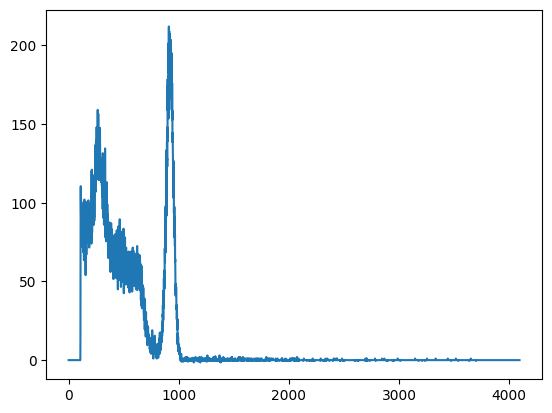

In [5]:
# simple plot of the data
plt.plot(df_cs["channel"],df_cs["data_bgsub"])
plt.show()

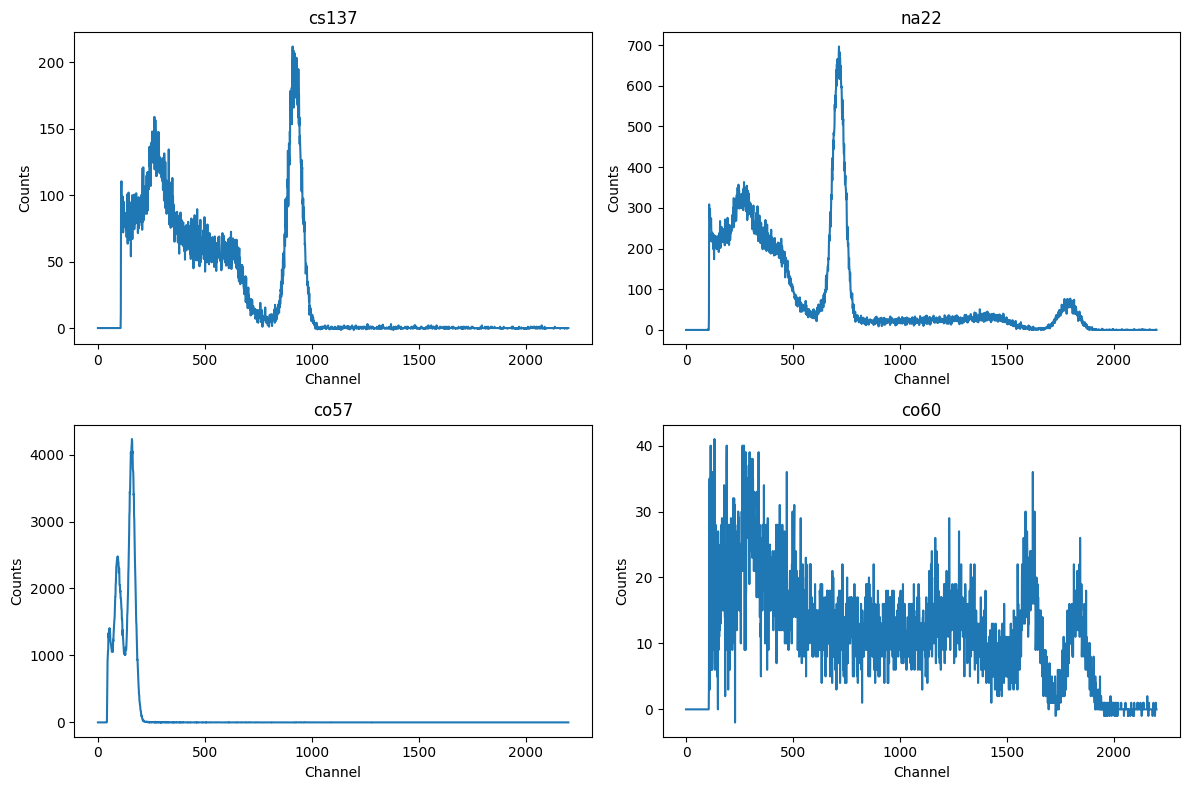

In [5]:
background_file = "./C3/background.Spe"

df_cs = read_spe_files("./C3/Cs137.Spe", background_file)
df_na = read_spe_files("./C3/Na 22 coin.Spe", background_file)
df_co57 = read_spe_files("./C3/Co 57.Spe", background_file)
df_co60 = read_spe_files("./C3/Co 60.Spe", background_file)

# Create subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# List of datasets for easy looping
datasets = [
    (df_cs, "cs137"),
    (df_na, "na22"),
    (df_co57, "co57"),
    (df_co60, "co60")
]

# Loop through datasets and axes
for ax, (df, title) in zip(axes.flatten(), datasets):
    ax.plot(df["channel"][:2200], df["data_bgsub"][:2200])
    ax.set_title(title)
    ax.set_xlabel("Channel")
    ax.set_ylabel("Counts")

# Adjust layout
plt.tight_layout()
plt.savefig("./Graphs/all_sources.png", dpi=300)
plt.show()


Questions:
>- Can you name the features shown in the spectrum?
>- Is the data taking up the full channel range, if not why?

Now you need to obtain the location of the photopeak energy. At this point, consider the shape of the photopeak and how you can use this knowledge to fit an appropriate model and extract its parameters. Note that the uncertainty on the peak position is required. Ask the demonstrators if you are unsure and need some pointers. 

In [6]:
# ==============================================================================
# GAUSSIAN PEAK FITTING FUNCTIONS
# ==============================================================================

def gaussian(x, amplitude, mean, sigma, background):
    """
    Gaussian function with constant background.
    
    Parameters:
    -----------
    x : array
        Channel numbers
    amplitude : float
        Height of the peak above background
    mean : float
        Center position of the peak
    sigma : float
        Standard deviation (width) of the Gaussian
    background : float
        Constant background level
    
    Returns:
    --------
    array : Gaussian + background values
    """
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma)**2) + background


# ==============================================================================
# GAUSSIAN PEAK FITTING WITH FLEXIBLE BACKGROUND
# ==============================================================================

def fit_photopeak(
    df,
    channel_min,
    channel_max,
    initial_centroid,
    initial_amplitude,
    initial_sigma,
    initial_background,
    background_type='quadratic',
    plot=True,
    title="Photopeak Fit"
):
    """
    Fit a Gaussian to a photopeak with flexible background.

    Parameters:
    -----------
    df : pandas DataFrame
        Spectrum data with columns: channel, data_bgsub, err_data_bgsub
    channel_min, channel_max : int
        Range of channels to fit
    initial_centroid : float
        Starting guess for peak center (channel number)
    initial_amplitude : float
        Starting guess for peak height above background
    initial_sigma : float
        Starting guess for peak width (FWHM ≈ 2.355 × sigma)
    initial_background : float or list
        Starting guess for background parameters
    background_type : str
        'constant', 'linear', or 'quadratic'
    plot : bool
        Whether to plot the fit
    title : str
        Title for the plot

    Returns:
    --------
    dict : Dictionary containing all fit results and uncertainties
    """

    # Extract data in the specified range
    mask = (df["channel"] >= channel_min) & (df["channel"] <= channel_max)
    x_data = df.loc[mask, "channel"].values
    y_data = df.loc[mask, "data_bgsub"].values
    y_err = df.loc[mask, "err_data_bgsub"].values

    if len(x_data) < 10:
        raise ValueError(
            f"Only {len(x_data)} data points. Need at least 10."
        )

    y_err = np.where(y_err > 0, y_err, 1.0)

    # Define model based on background type
    if background_type == 'constant':
        def model(x, amplitude, mean, sigma, bg_c):
            gauss = amplitude * np.exp(-0.5 * ((x - mean) / sigma)**2)
            return gauss + bg_c

        if isinstance(initial_background, (list, tuple)):
            bg_init = initial_background[0]
        else:
            bg_init = initial_background
        initial_guess = [
            initial_amplitude, initial_centroid, initial_sigma, bg_init
        ]

    elif background_type == 'linear':
        def model(x, amplitude, mean, sigma, bg_a, bg_b):
            gauss = amplitude * np.exp(-0.5 * ((x - mean) / sigma)**2) 
            return gauss + bg_a + bg_b * x

        if isinstance(initial_background, (list, tuple)):
            bg_init = list(initial_background)
        else:
            slope = (y_data[-1] - y_data[0]) / (x_data[-1] - x_data[0])
            bg_init = [y_data[0] - slope * x_data[0], slope]
        initial_guess = [
            initial_amplitude, initial_centroid, initial_sigma
        ] + bg_init

    elif background_type == 'quadratic':
        def model(x, amplitude, mean, sigma, bg_a, bg_b, bg_c):
            gauss = amplitude * np.exp(-0.5 * ((x - mean) / sigma)**2)
            return gauss + bg_a + bg_b * x + bg_c * x**2

        if isinstance(initial_background, (list, tuple)):
            bg_init = list(initial_background)
        else:
            bg_init = [initial_background, 0.0, 0.0]
        initial_guess = [
            initial_amplitude, initial_centroid, initial_sigma
        ] + bg_init

    else:
        raise ValueError(f"Unknown background_type: {background_type}")

    # Perform fit
    try:
        popt, pcov = curve_fit(
            model, x_data, y_data,
            p0=initial_guess,
            sigma=y_err,
            absolute_sigma=True,
            maxfev=10000
        )
    except RuntimeError as e:
        print(f"  Fit failed: {e}")
        return None

    # Extract peak parameters (always first 3)
    amplitude, mean, sigma = popt[:3]
    perr = np.sqrt(np.diag(pcov))
    amplitude_err, mean_err, sigma_err = perr[:3]

    # Background parameters
    bg_params = popt[3:]
    bg_errors = perr[3:]

    fwhm = 2.355 * sigma
    fwhm_err = 2.355 * sigma_err

    # Calculate fit quality
    y_fit = model(x_data, *popt)
    residuals = y_data - y_fit
    chi_squared = np.sum(((y_data - y_fit) / y_err)**2)
    dof = len(x_data) - len(popt)
    reduced_chi_squared = chi_squared / dof

    print(f"\nFitting {title}")
    print(f"  Range: {channel_min}-{channel_max}, "
          f"Background: {background_type}")
    print(f"  Peak: {mean:.2f}±{mean_err:.2f}, "
          f"FWHM: {fwhm:.2f}±{fwhm_err:.2f}, "
          f"χ²/dof: {reduced_chi_squared:.2f}")

    # Plotting
    if plot:
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(12, 8),
            gridspec_kw={'height_ratios': [3, 1]}
        )

        # Top panel: Data and fit
        ax1.errorbar(
            x_data, y_data, yerr=y_err,
            fmt='o', markersize=5, capsize=3,
            label='Data (background subtracted)',
            color='blue', alpha=0.6, zorder=2
        )

        # Smooth curve for the fit
        x_fit = np.linspace(x_data[0], x_data[-1], 500)
        y_fit_smooth = model(x_fit, *popt)
        ax1.plot(
            x_fit, y_fit_smooth, 'r-', linewidth=2.5,
            label='Gaussian Fit', zorder=3
        )

        # Mark peak position
        ax1.axvline(
            mean, color='green', linestyle='--',
            alpha=0.7, linewidth=1.5,
            label=f'Peak: {mean:.2f} ± {mean_err:.2f}',
            zorder=1
        )

        # Show FWHM
        bg_at_peak = model(mean, *popt) - amplitude * np.exp(0)
        half_max = amplitude/2 + bg_at_peak
        fwhm_left = mean - abs(fwhm)/2
        fwhm_right = mean + abs(fwhm)/2

        ax1.axhline(
            half_max, color='orange', linestyle=':',
            alpha=0.6, linewidth=1.5, zorder=1
        )
        ax1.axvspan(
            fwhm_left, fwhm_right, alpha=0.1, color='orange',
            label=f'FWHM: {fwhm:.2f} ± {fwhm_err:.2f}'
        )

        ax1.set_ylabel('Counts', fontsize=12, fontweight='bold')
        ax1.set_title(
            f'{title} | χ²/dof = {reduced_chi_squared:.2f}',
            fontsize=13, fontweight='bold'
        )
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.3, linestyle='--')

        # Bottom panel: Residuals
        normalized_residuals = residuals / y_err

        ax2.errorbar(
            x_data, normalized_residuals, yerr=1.0,
            fmt='o', markersize=4, capsize=2,
            color='purple', alpha=0.6
        )
        ax2.axhline(0, color='red', linestyle='-', linewidth=1.5, alpha=0.7)
        ax2.axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.4)
        ax2.axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.4)

        ax2.set_xlabel('Channel Number', fontsize=12, fontweight='bold')
        ax2.set_ylabel(
            'Normalized\nResiduals (σ)',
            fontsize=10, fontweight='bold'
        )
        ax2.grid(True, alpha=0.3, linestyle='--')
        ax2.set_ylim([-5, 5])

        plt.tight_layout()
        plt.show()

    return {
        'centroid': mean,
        'centroid_err': mean_err,
        'amplitude': amplitude,
        'amplitude_err': amplitude_err,
        'sigma': sigma,
        'sigma_err': sigma_err,
        'fwhm': fwhm,
        'fwhm_err': fwhm_err,
        'background_params': bg_params,
        'background_errors': bg_errors,
        'reduced_chi_squared': reduced_chi_squared,
        'residuals': residuals,
        'normalized_residuals': normalized_residuals
    }


PHOTOPEAK ANALYSIS


Fitting cs137_662keV...

Fitting cs137 662keV
  Range: 850-1050, Background: quadratic
  Peak: 921.22±0.43, FWHM: 73.76±1.04, χ²/dof: 0.91


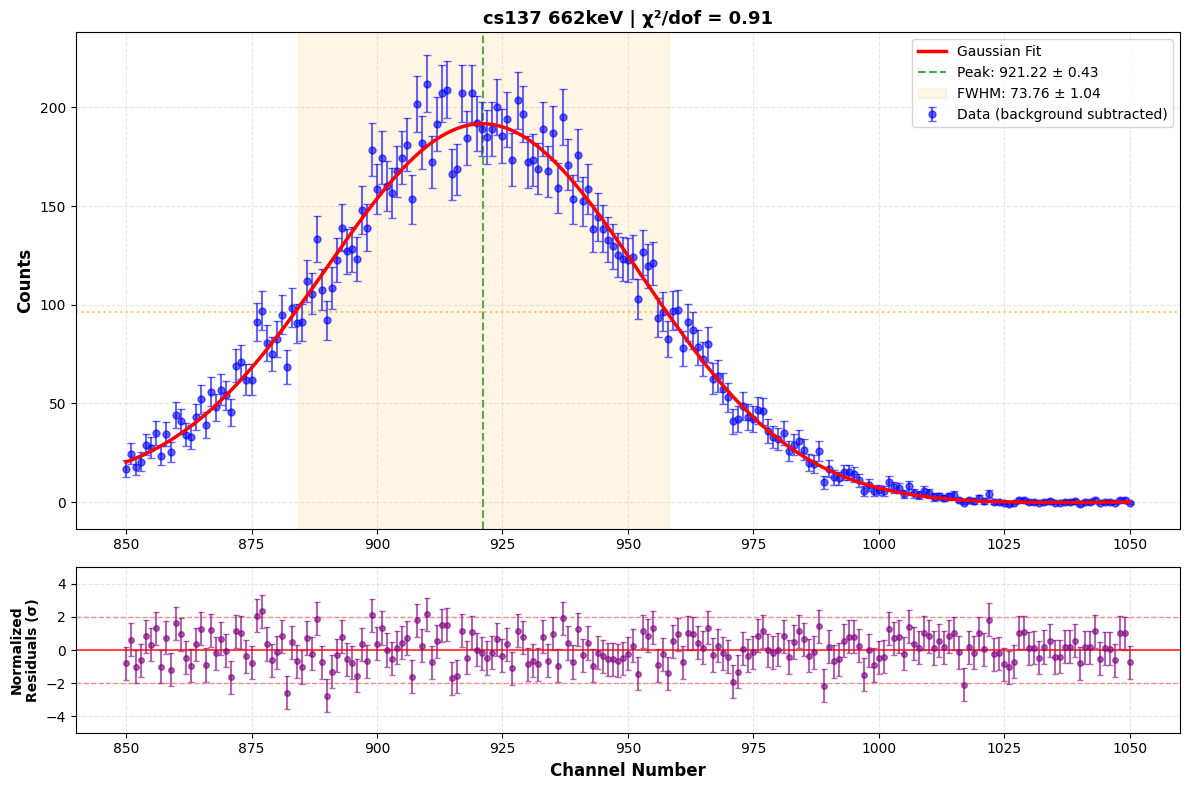


Fitting na22_511keV...

Fitting na22 511keV
  Range: 600-820, Background: quadratic
  Peak: 713.40±0.16, FWHM: 64.46±0.57, χ²/dof: 1.19


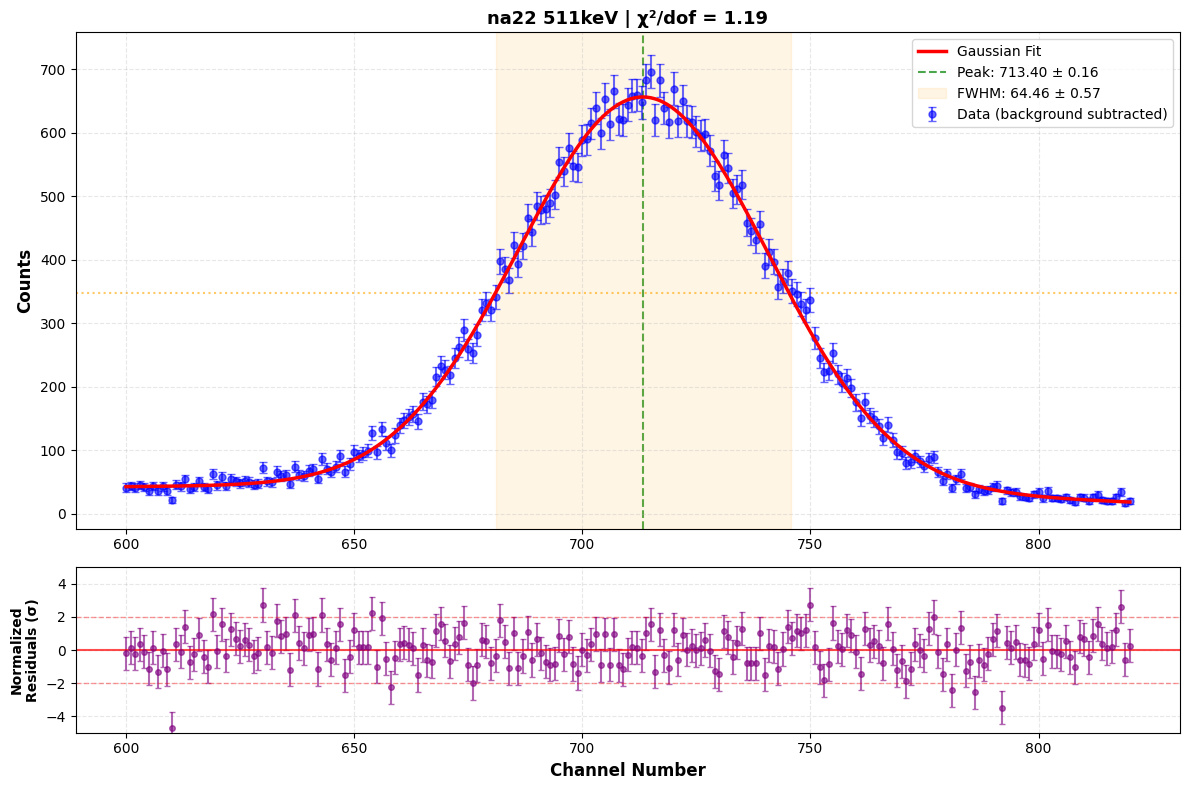


Fitting na22_1275keV...

Fitting na22 1275keV
  Range: 1600-1900, Background: quadratic
  Peak: 1786.94±0.64, FWHM: 100.05±1.79, χ²/dof: 1.27


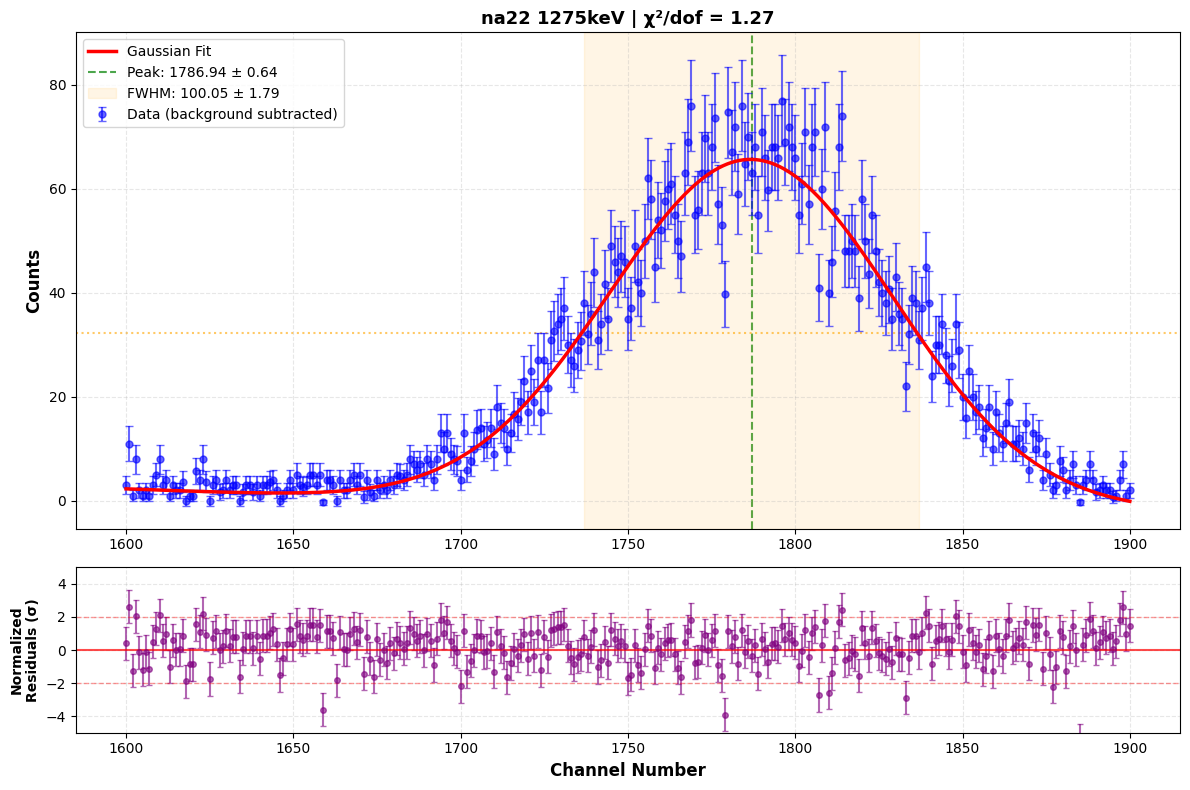


Fitting co57_122keV...

Fitting co57 122keV
  Range: 120-220, Background: quadratic
  Peak: 159.75±0.06, FWHM: 31.95±0.15, χ²/dof: 4.25


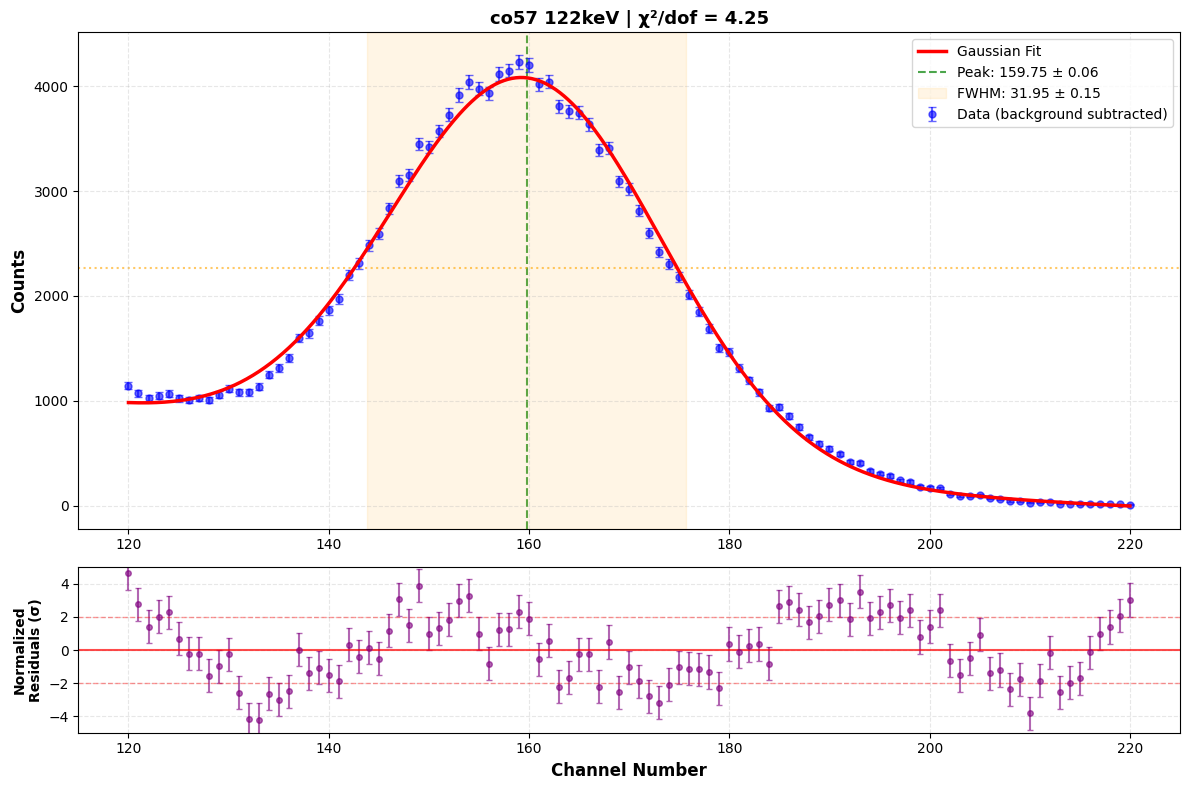


Fitting co60_1173keV...

Fitting co60 1173keV
  Range: 1525-1750, Background: linear
  Peak: 1608.18±1.98, FWHM: 86.51±5.85, χ²/dof: 1.12


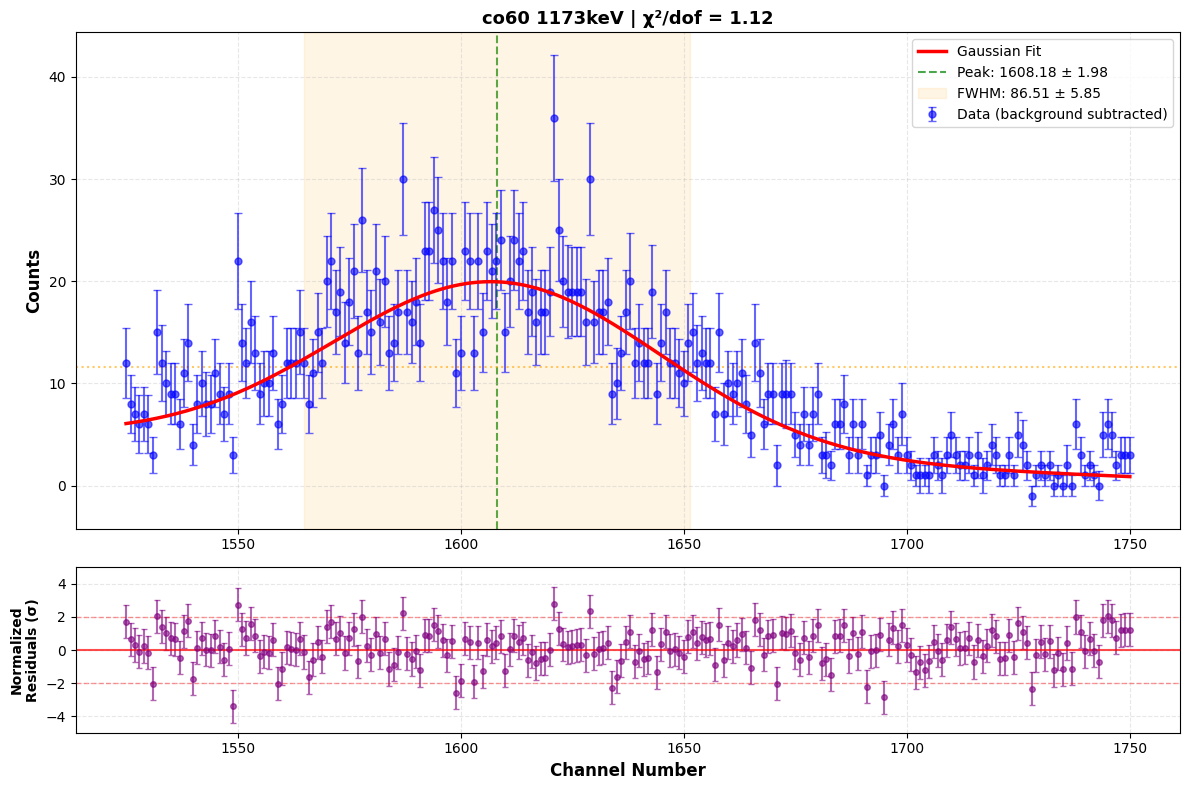


Fitting co60_1332keV...

Fitting co60 1332keV
  Range: 1725-1950, Background: linear
  Peak: 1829.32±1.46, FWHM: 92.42±4.01, χ²/dof: 0.87


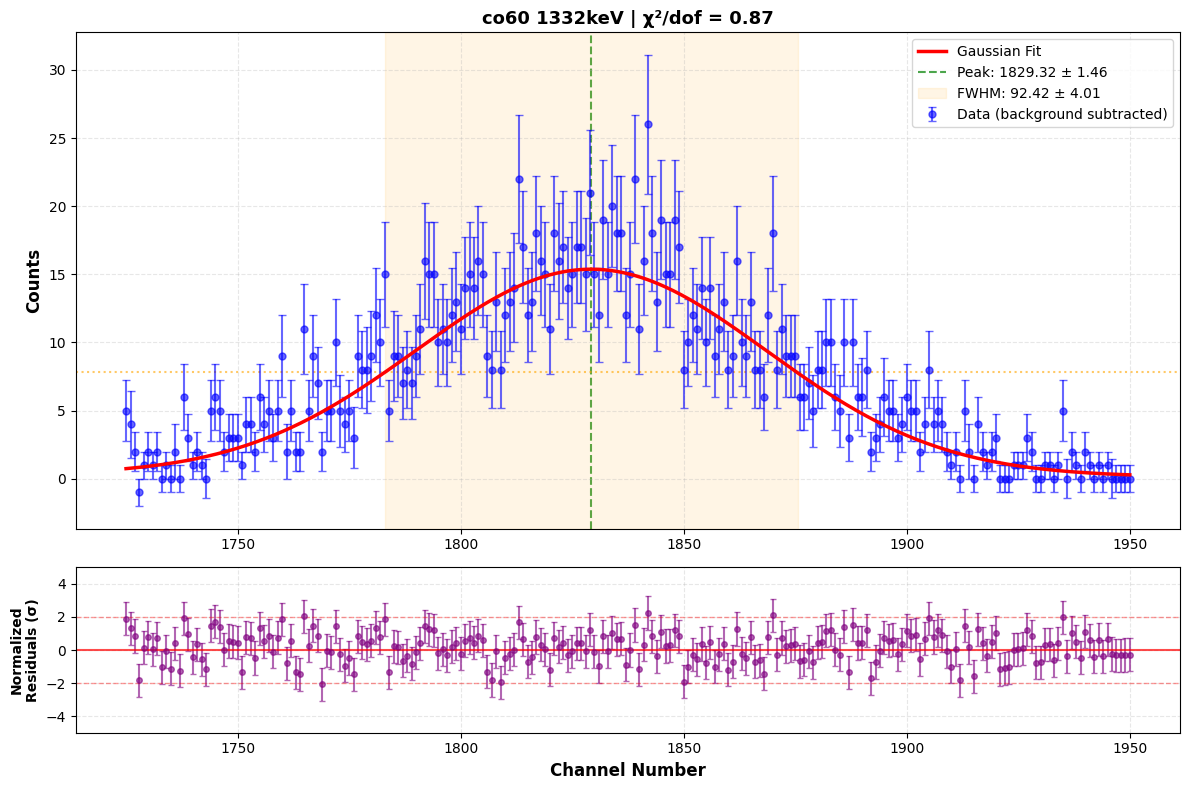


╔══════════════════════════════════════════════════════════════════════════════╗
║                          FITTED PHOTOPEAKS SUMMARY                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ Peak                 Centroid (ch)             FWHM (ch)                 ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ cs137_662keV          921.22 ± 0.43          73.76 ± 1.04      ║
║ na22_511keV           713.40 ± 0.16          64.46 ± 0.57      ║
║ na22_1275keV         1786.94 ± 0.64         100.05 ± 1.79      ║
║ co57_122keV           159.75 ± 0.06          31.95 ± 0.15      ║
║ co60_1173keV         1608.18 ± 1.98          86.51 ± 5.85      ║
║ co60_1332keV         1829.32 ± 1.46          92.42 ± 4.01      ║
╚══════════════════════════════════════════════════════════════════════════════╝



In [39]:
# ==============================================================================
# PHOTOPEAK ANALYSIS - COMPACT VERSION WITH PLOTS
# ==============================================================================

# Configuration: all peaks in one place
peak_configs = {
    'cs137_662keV': {
        'df': df_cs,
        'ch_min': 850, 'ch_max': 1050,
        'centroid': 950, 'amplitude': 200, 'sigma': 12, 'background': 10,
        'bg_type': 'quadratic'
    },
    'na22_511keV': {
        'df': df_na,
        'ch_min': 600, 'ch_max': 820,
        'centroid': 710, 'amplitude': 650, 'sigma': 25, 'background': 50,
        'bg_type': 'quadratic'
    },
    'na22_1275keV': {
        'df': df_na,
        'ch_min': 1600, 'ch_max': 1900,
        'centroid': 1750, 'amplitude': 80, 'sigma': 50, 'background': 20,
        'bg_type': 'quadratic'
    },
    'co57_122keV': {
        'df': df_co57,
        'ch_min': 120, 'ch_max': 220,
        'centroid': 160, 'amplitude': 4200, 'sigma': 20, 'background': 100,
        'bg_type': 'quadratic'
    },
    'co60_1173keV': {
        'df': df_co60,
        'ch_min': 1525, 'ch_max': 1750,  # Adjusted range
        'centroid': 1600, 'amplitude': 20, 'sigma': 85, 'background': 8,  # Better initial guess
        'bg_type': 'linear'
    },
    'co60_1332keV': {
        'df': df_co60,
        'ch_min': 1725, 'ch_max': 1950,  # Adjusted range
        'centroid': 1850, 'amplitude': 17, 'sigma': 85, 'background': 4,  # Better initial guess
        'bg_type': 'linear'
    }
}

# Fit all peaks
print("\n" + "="*80)
print("PHOTOPEAK ANALYSIS")
print("="*80 + "\n")

fit_results = pd.DataFrame()

for name, config in peak_configs.items():
    print(f"\nFitting {name}...")
    
    result = fit_photopeak(
        config['df'],
        channel_min=config['ch_min'],
        channel_max=config['ch_max'],
        initial_centroid=config['centroid'],
        initial_amplitude=config['amplitude'],
        initial_sigma=config['sigma'],
        initial_background=config['background'],
        background_type=config['bg_type'],  # Added this
        plot=True,  # This ensures plots are shown
        title=f"{name.replace('_', ' ')}"
    )
    
    if result:
        fit_results = pd.concat([fit_results, pd.DataFrame([{
            'photopeak': name,
            'centroid': result['centroid'],
            'centroid_err': result['centroid_err'],
            'fwhm': result['fwhm'],
            'fwhm_err': result['fwhm_err'],
            'amplitude': result['amplitude'],
            'amplitude_err': result['amplitude_err']
        }])], ignore_index=True)

# Display summary
print("\n" + "╔" + "═"*78 + "╗")
print(f"║ {'FITTED PHOTOPEAKS SUMMARY':^76} ║")
print("╠" + "═"*78 + "╣")
print(f"║ {'Peak':<20} {'Centroid (ch)':<25} {'FWHM (ch)':<25} ║")
print("╠" + "═"*78 + "╣")

for _, row in fit_results.iterrows():  # Fixed typo: for *, row
    print(f"║ {row['photopeak']:<20} "
          f"{row['centroid']:>7.2f} ± {row['centroid_err']:<8.2f}    "
          f"{row['fwhm']:>7.2f} ± {row['fwhm_err']:<8.2f}  ║")

print("╚" + "═"*78 + "╝\n")

At this stage, check with a demonstrator that your code is correct and that you have obtained a reasonable value. Now repeat the above using Co-60, Na-22 and Am-241. Ask a demonstrator when you want to use the Na-22 source, which will have a shorter acquisition time and so will require a new background.  Note the shape of the photopeaks of Co-60 and how you should adapt your model to reflect this. 

Questions:
>- When fitting the photopeak, which fitting function is recommended—Gaussian, Lorentzian, or something else?
>- How do you identify multiple peaks in the spectrum if they overlap?

## <span style="color:red">Section 2 - Energy calibration fitting</span>

It is important to properly calibrate the readouts from the SiPM so that the spectra obtained can be expressed as a function of energy (rather than of channel numbers, which are somewhat arbitrary and very dependent on equipment, settings, etc.).

Using the table of known photopeak energies below, create an energy calibration graph of photopeak energy as a function of channel number. Consider what type of function you think would best represent the relationship.  If you are unsure, consider creating a scatter plot of your data. 

You should take into account the error on your photopeak measurements but, for the purposes of this lab, the photopeak energies quoted below can be assumed to have no uncertainty. 

<<table border="1" cellspacing="0" cellpadding="4" style="margin-left:auto; margin-right:auto; border-collapse: collapse;">
  <tr>
    <th>Isotope</th>
    <th>Photopeak (keV)</th>
  </tr>
  <tr>
    <td>Co-57</td>
    <td>122</td>
  </tr>
  <tr>
    <td rowspan="2">Co-60</td>
    <td>1172</td>
  </tr>
  <tr>
    <td>1333</td>
  </tr>
  <tr>
    <td>Cs-137</td>
    <td>662</td>
  </tr>
  <tr>
    <td rowspan="2">Na-22</td>
    <td>511</td>
  </tr>
  <tr>
    <td>1275</td>
  </tr>
</table>



##Demos only##

It is tricky to use the errors on x (our data) in this case. What I usually do is convert $y=mx+c$ to $x=\frac{y}{m}-\frac{c}{m} = m'y+c'$, fit this normally and convert back. This means the error on $m,c$ are the following (rigorously you can include the cross term of c,m in the second eq but this doesn't impact the final result too much so can be ignored):

$$
\Delta m = \frac{\Delta m'}{(m')^2}
$$

$$
\Delta c = \sqrt{(\frac{\Delta c'}{m'})^2+(\frac{c\Delta m'}{(m')^2})^2}
$$

I leave the proof of this as an exercise to the reader. 

You can also use orthogonal distance regression to do the same thing without the need to flip the straight-line equation. I've included code for that as well. 

In [40]:
# ==============================================================================
# CREATE ENERGY CALIBRATION CURVE
# ==============================================================================

def create_calibration_curve_with_uncertainties(
    calibration_data, plot=True, save_fig=True
):
    """
    Create energy calibration curve with proper uncertainty calculation.
    Returns slope, intercept, and their uncertainties.
    """

    channels = np.array(calibration_data['channel'])
    energies = np.array(calibration_data['energy_keV'])
    channel_errors = np.array(calibration_data['channel_err'])

    # Weighted linear fit
    weights = 1.0 / (channel_errors**2)

    # Use numpy polyfit with covariance
    fit_coeffs, cov_matrix = np.polyfit(
        channels, energies, 1, w=weights, cov=True
    )
    m, c = fit_coeffs  # slope and intercept

    # Extract uncertainties from covariance matrix
    m_err = np.sqrt(cov_matrix[0, 0])
    c_err = np.sqrt(cov_matrix[1, 1])

    # Calculate fit statistics
    energy_fit = m * channels + c
    residuals = energies - energy_fit

    # R² value
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((energies - np.mean(energies))**2)
    r_squared = 1 - (ss_res / ss_tot)

    # RMSE
    rmse = np.sqrt(np.mean(residuals**2))

    # Reduced chi-squared
    chi_squared = np.sum(((residuals) / channel_errors)**2)
    dof = len(channels) - 2
    reduced_chi_squared = chi_squared / dof

    print("\n" + "╔" + "═"*68 + "╗")
    print(f"║ {'ENERGY CALIBRATION RESULTS':^66} ║")
    print("╠" + "═"*68 + "╣")
    print(f"║  Slope (m):      {m:.6f} ± {m_err:.6f} keV/ch        ║")
    print(f"║  Intercept (c):  {c:.4f} ± {c_err:.4f} keV              ║")
    print(f"║  R²:             {r_squared:.6f}                         ║")
    print(f"║  RMSE:           {rmse:.3f} keV                          ║")
    print(f"║  Reduced χ²:     {reduced_chi_squared:.3f}               ║")
    print("╠" + "═"*68 + "╣")
    print(f"║  Linear fit: E = ({m:.6f} ± {m_err:.6f}) × Ch        ║")
    print(f"║                  + ({c:.4f} ± {c_err:.4f})           ║")
    print("╚" + "═"*68 + "╝\n")

    if plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

        # Top plot: Calibration curve
        ax1.errorbar(
            channels, energies, xerr=channel_errors,
            fmt='o', markersize=10, capsize=5, color='blue',
            elinewidth=2, capthick=2, label='Measured peaks'
        )

        # Fit line
        ch_range = np.linspace(
            channels.min() * 0.9, channels.max() * 1.1, 100
        )
        fit_label = (
            f'E = ({m:.6f}±{m_err:.6f})×Ch + ({c:.2f}±{c_err:.2f})\n'
            f'R² = {r_squared:.6f}'
        )
        ax1.plot(
            ch_range, m * ch_range + c, 'r--',
            linewidth=3, label=fit_label
        )

        # Annotate each point
        for i, source in enumerate(calibration_data['source']):
            ax1.annotate(
                f"{source}\n{energies[i]:.0f} keV",
                (channels[i], energies[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=8, alpha=0.7
            )

        ax1.set_xlabel('Channel Number', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Energy (keV)', fontsize=12, fontweight='bold')
        ax1.set_title(
            'Energy Calibration Curve',
            fontsize=14, fontweight='bold'
        )
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)

        # Bottom plot: Residuals
        ax2.errorbar(
            channels, residuals, xerr=channel_errors,
            fmt='o', markersize=8, capsize=5, color='green'
        )
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlabel('Channel Number', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Residual (keV)', fontsize=12, fontweight='bold')
        ax2.set_title('Fit Residuals', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_fig:
            plt.savefig(
                "./Graphs/energy_calibration.png",
                dpi=300, bbox_inches='tight'
            )
            print("✓ Saved to ./Graphs/energy_calibration.png")

        plt.show()

    return {
        'slope': m,
        'slope_err': m_err,
        'intercept': c,
        'intercept_err': c_err,
        'r_squared': r_squared,
        'residuals': residuals,
        'rmse': rmse,
        'reduced_chi_squared': reduced_chi_squared,
        'covariance_matrix': cov_matrix
    }


def apply_calibration(df, slope, intercept):
    """Add calibrated energy column to dataframe."""
    df_copy = df.copy()
    df_copy['energy_keV'] = slope * df_copy['channel'] + intercept
    print(f"✓ Added 'energy_keV' column: "
          f"E = {slope:.6f} × Ch + {intercept:.4f}")
    return df_copy


╔══════════════════════════════════════════════════════════════════════════════╗
║                      CREATING ENERGY CALIBRATION CURVE                       ║
╚══════════════════════════════════════════════════════════════════════════════╝


╔════════════════════════════════════════════════════════════════════╗
║                     ENERGY CALIBRATION RESULTS                     ║
╠════════════════════════════════════════════════════════════════════╣
║  Slope (m):      0.703065 ± 0.000906 keV/ch        ║
║  Intercept (c):  9.6842 ± 0.1683 keV              ║
║  R²:             0.997930                         ║
║  RMSE:           20.324 keV                          ║
║  Reduced χ²:     299.166               ║
╠════════════════════════════════════════════════════════════════════╣
║  Linear fit: E = (0.703065 ± 0.000906) × Ch        ║
║                  + (9.6842 ± 0.1683)           ║
╚════════════════════════════════════════════════════════════════════╝

✓ Saved to ./Graphs/energy_ca

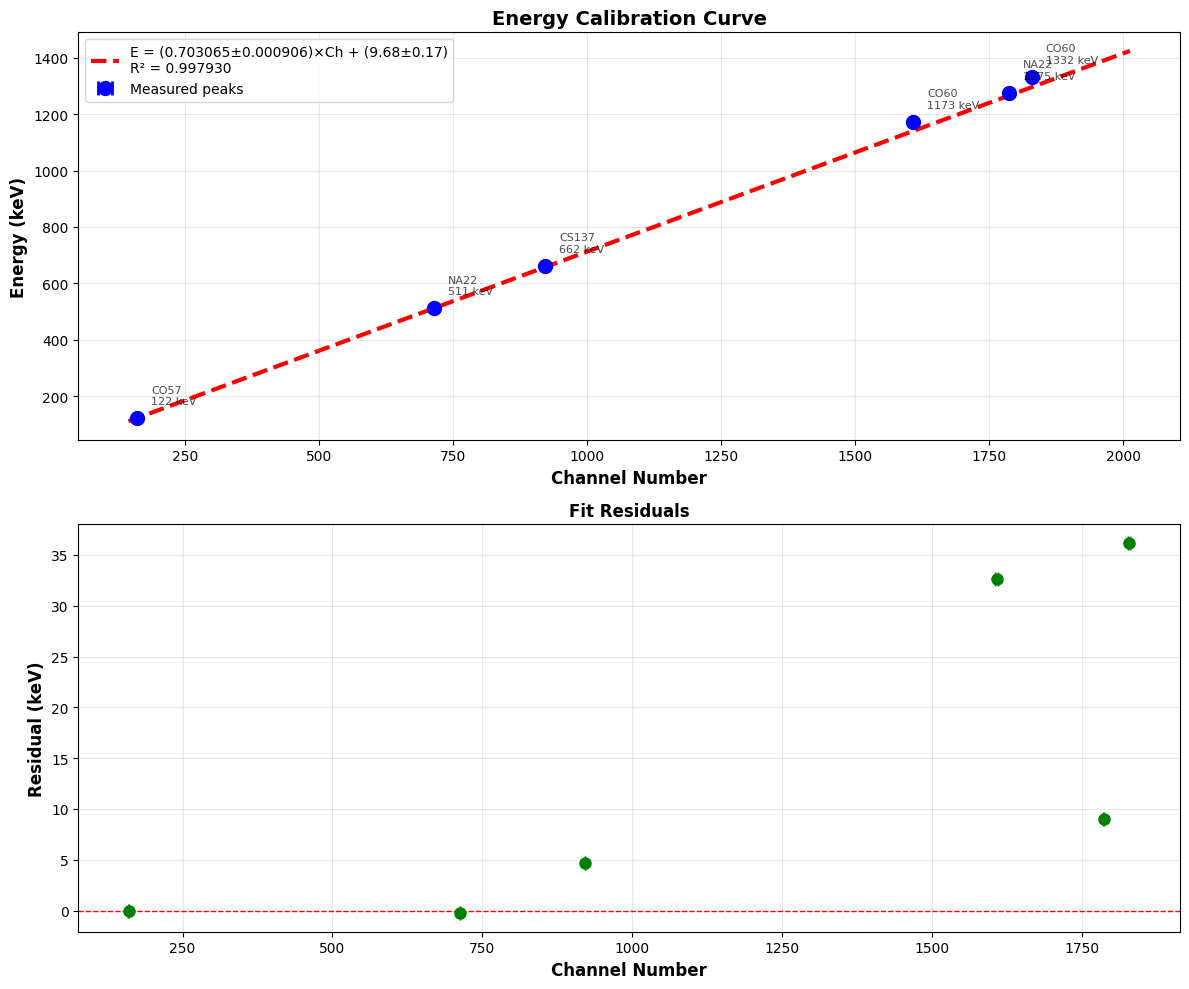


────────────────────────────────────────────────────────────────────────────────
Applying calibration to all spectra...
────────────────────────────────────────────────────────────────────────────────

✓ Added 'energy_keV' column: E = 0.703065 × Ch + 9.6842
✓ Added 'energy_keV' column: E = 0.703065 × Ch + 9.6842
✓ Added 'energy_keV' column: E = 0.703065 × Ch + 9.6842
✓ Added 'energy_keV' column: E = 0.703065 × Ch + 9.6842
✓ Calibration parameters saved

✓ Fit results saved to ./photopeak_fit_results.csv

ANALYSIS COMPLETE!



In [41]:
# ===============================================
# BUILD CALIBRATION DATA FROM FITTED PEAKS
# ===============================================

print("\n" + "╔" + "═"*78 + "╗")
print(f"║ {'CREATING ENERGY CALIBRATION CURVE':^76} ║")
print("╚" + "═"*78 + "╝\n")

# Map peak names to known energies
known_energies = {
    'cs137_662keV': 662,
    'na22_511keV': 511,
    'na22_1275keV': 1275,
    'co57_122keV': 122,
    'co60_1173keV': 1173,
    'co60_1332keV': 1332
}

calibration_data = {
    'source': [],
    'energy_keV': [],
    'channel': [],
    'channel_err': []
}

# Extract from fit_results DataFrame
for _, row in fit_results.iterrows():
    peak_name = row['photopeak']
    if peak_name in known_energies:
        source = peak_name.split('_')[0]
        calibration_data['source'].append(source.upper())
        calibration_data['energy_keV'].append(known_energies[peak_name])
        calibration_data['channel'].append(row['centroid'])
        calibration_data['channel_err'].append(row['centroid_err'])

# Perform calibration
if len(calibration_data['channel']) >= 2:
    calibration = create_calibration_curve_with_uncertainties(
        calibration_data, plot=True, save_fig=True
    )

    # Apply to all spectra
    print("\n" + "─"*80)
    print("Applying calibration to all spectra...")
    print("─"*80 + "\n")

    df_cs_cal = apply_calibration(
        df_cs, calibration['slope'], calibration['intercept']
    )
    df_na_cal = apply_calibration(
        df_na, calibration['slope'], calibration['intercept']
    )
    df_co57_cal = apply_calibration(
        df_co57, calibration['slope'], calibration['intercept']
    )
    df_co60_cal = apply_calibration(
        df_co60, calibration['slope'], calibration['intercept']
    )

    # Save calibration parameters
    cal_df = pd.DataFrame({
        'parameter': [
            'slope', 'slope_err', 'intercept',
            'intercept_err', 'r_squared'
        ],
        'value': [
            calibration['slope'],
            calibration['slope_err'],
            calibration['intercept'],
            calibration['intercept_err'],
            calibration['r_squared']
        ]
    })
    cal_df.to_csv("./energy_calibration_parameters.csv", index=False)
    print("✓ Calibration parameters saved\n")

else:
    print("⚠️  Not enough peaks for calibration (need at least 2)\n")

# Save fit results
fit_results.to_csv("./photopeak_fit_results.csv", index=False)
print("✓ Fit results saved to ./photopeak_fit_results.csv")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80 + "\n")

Questions:
>- How do we get the uncertainty in Energy based on the uncertainty in channel number?

## <span style="color:red">Section 3 - Resolution of the Detector</span>


At this stage you should compute the Full Width Half Maximum (FWHM) for each of the photopeaks. This can be obtained by multiplying the standard deviation of the photopeak by 2.355 (specifically $2\sqrt{2ln2}$). The uncertainty in the FWHM should also be obtained. 

The finite width of the observed photopeaks is a result of the same energy deposit in a detector not giving the same pulse height for successive measurements. This is because there is an intrinsic variation in the number of (in this case) optical scintillation photons, subject to the familiar counting statistics rules. The spread is proportional to $\sqrt{N}$, where $N$ is the total number of optical scintillation photons for a given energy deposit. It is not possible to reliably simulate a detector system without first determining how this resolution varies with the energy of the incident radiation.

The resolution of a photopeak is defined as:

$$
R = \frac{\text{FWHM}}{E} = k E^n
$$


Where $E$ is the photopeak $\gamma$-ray energy and $k,n$ are constants. 

Using your energy calibrated values:
- Find the resolution for each of the photopeaks. 
- Plot your resolution values as a function of photopeak energy. 
- Using the equation above, determine values for $k,n$. Consider also if there are any mathematical operations that can be applied to the equation to make the resulting model easier to fit. 

Questions:
>- What does the extracted value of $n$ tell you about the operation of this type of scintillation detector?
>- How does your extracted $n$ comapre to the expected value? What does this suggest?


SECTION 3: DETECTOR RESOLUTION ANALYSIS

Calibration: E = 0.703065 × Ch + 9.6842
Uncertainties: σ_m = 0.000906, σ_c = 0.1683

Valid peaks: 6/6

--------------------------------------------------------------------------------

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                               DETECTOR RESOLUTION SUMMARY                                ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║ Peak                 Energy (keV)         FWHM (keV)           Resolution           ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║ cs137_662keV           657.4 ± 0.9         51.86 ± 0.73       0.0789 ± 0.0011  ║
║ na22_511keV            511.3 ± 0.7         45.32 ± 0.41       0.0886 ± 0.0008  ║
║ na22_1275keV          1266.0 ± 1.7         70.34 ± 1.26       0.0556 ± 0.0010  ║
║ co57_122keV            122.0 ± 0.2         22.46 ± 0.11       

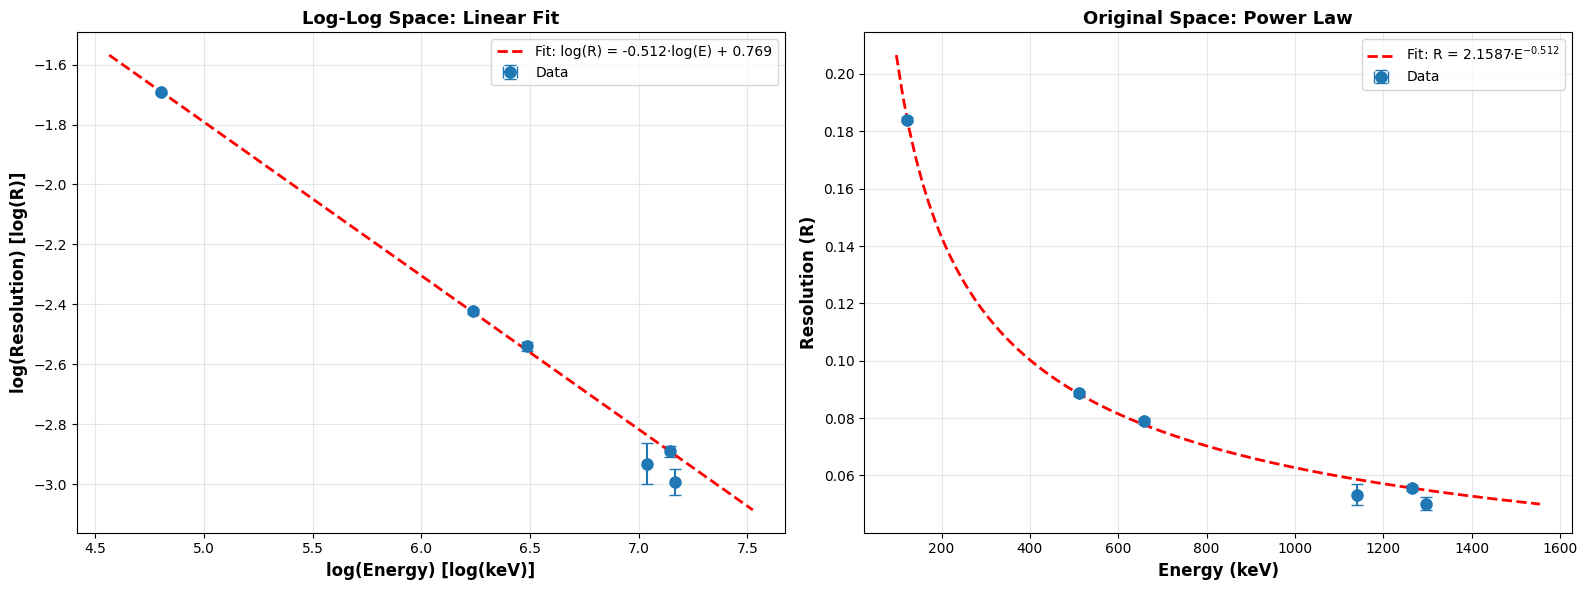

METHOD 2: ODR in Log-Log Space
--------------------------------------------------------------------------------
Power law: R = k × E^n
  n           = -0.512292 ± 0.006951
  k           = 2.158964 ± 0.082188
  log k       = 0.769629 ± 0.038068
  Reduced χ²  = 1.869



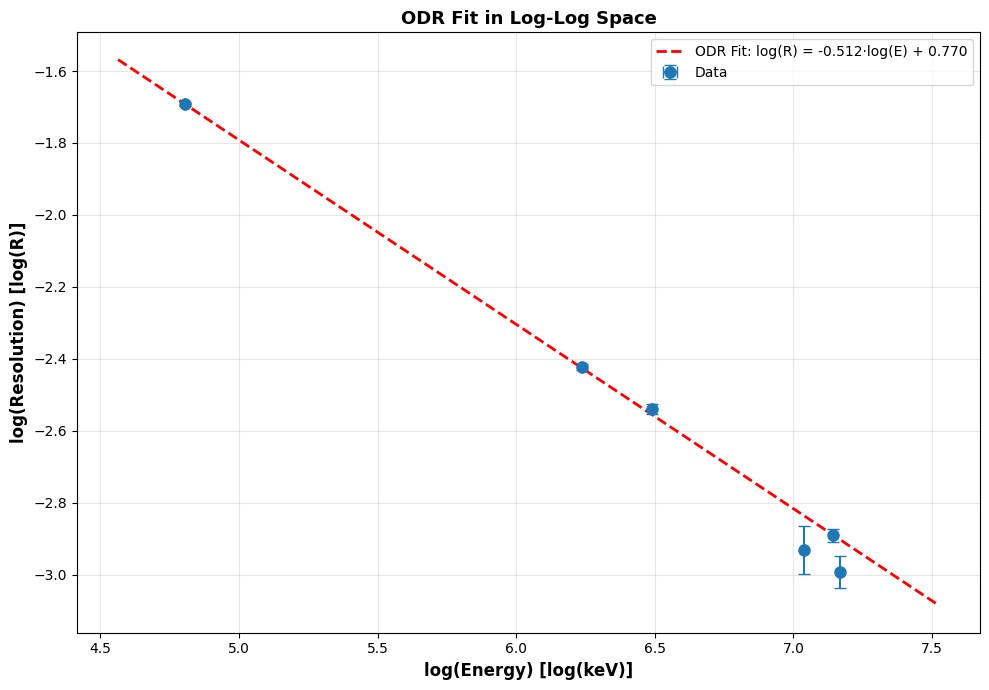

METHOD 3: ODR in Original Space
--------------------------------------------------------------------------------
Power law: R = k × E^n
  n           = -0.512784 ± 0.007198
  k           = 2.164267 ± 0.085323
  Reduced χ²  = 2.016



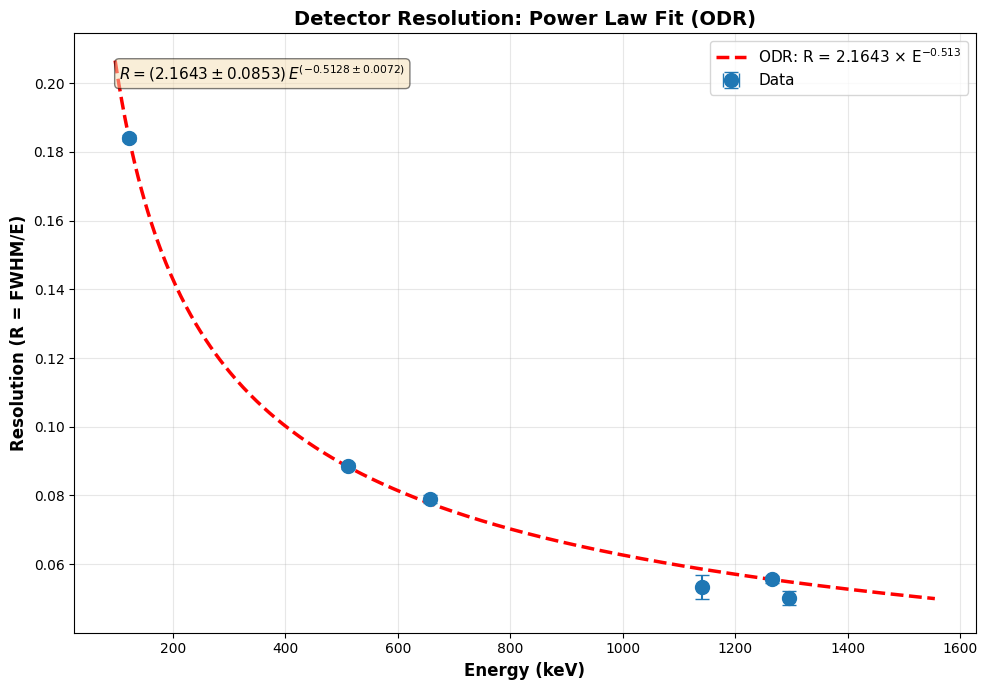


COMPARISON OF METHODS
Method                         n                         k                        
--------------------------------------------------------------------------------
Polyfit (log-log)              -0.512269 ± 0.006908    2.158666 ± 0.081491
ODR (log-log)                  -0.512292 ± 0.006951    2.158964 ± 0.082188
ODR (original)                 -0.512784 ± 0.007198    2.164267 ± 0.085323

✓ Resolution data saved to ./detector_resolution_data.csv
✓ Fit parameters saved to ./resolution_fits.csv

RESOLUTION ANALYSIS COMPLETE!



In [42]:
# ==============================================================================
# SECTION 3: DETECTOR RESOLUTION ANALYSIS
# ==============================================================================

from scipy.odr import ODR, Model, RealData

print("\n" + "="*80)
print("SECTION 3: DETECTOR RESOLUTION ANALYSIS")
print("="*80 + "\n")


# ==============================================================================
# Helper Functions
# ==============================================================================

def convert_to_energy_with_uncertainties(m, m_err, c, c_err, x, x_err):
    """
    Convert channel to energy: E = m*x + c
    σ_E² = (∂E/∂m)²σ_m² + (∂E/∂c)²σ_c² + (∂E/∂x)²σ_x²
         = x²σ_m² + σ_c² + m²σ_x²
    """
    E = m * x + c
    E_err = np.sqrt((x * m_err)**2 + c_err**2 + (m * x_err)**2)
    return E, E_err


def calc_resolution(e, e_err, fwhm, fwhm_err):
    """
    Calculate resolution R = FWHM/E with uncertainty propagation.
    σ_R = R * sqrt((σ_FWHM/FWHM)² + (σ_E/E)²)
    """
    r = fwhm / e
    r_err = r * np.sqrt((fwhm_err/fwhm)**2 + (e_err/e)**2)
    return r, r_err


# ==============================================================================
# Extract calibration parameters with uncertainties
# ==============================================================================

m = calibration['slope']
m_err = calibration['slope_err']
c = calibration['intercept']
c_err = calibration['intercept_err']

print(f"Calibration: E = {m:.6f} × Ch + {c:.4f}")
print(f"Uncertainties: σ_m = {m_err:.6f}, σ_c = {c_err:.4f}\n")


# ==============================================================================
# Filter bad fits and convert to energy
# ==============================================================================

fit_results_clean = fit_results[fit_results['fwhm'] > 0].copy()

print(f"Valid peaks: {len(fit_results_clean)}/{len(fit_results)}")

if len(fit_results_clean) < len(fit_results):
    print("\nSkipped peaks with invalid FWHM:")
    for idx, row in fit_results[fit_results['fwhm'] <= 0].iterrows():
        print(f"  - {row['photopeak']}: "
              f"FWHM = {row['fwhm']:.2f}")

print("\n" + "-"*80)

# Convert centroid to energy
fit_results_clean[["centroid_en", "centroid_en_err"]] = (
    fit_results_clean.apply(
        lambda row: convert_to_energy_with_uncertainties(
            m, m_err, c, c_err, row["centroid"], row["centroid_err"]
        ),
        axis=1,
        result_type="expand"
    )
)

# Convert FWHM to energy (FWHM is difference, so intercept cancels)
fit_results_clean[["fwhm_en", "fwhm_en_err"]] = (
    fit_results_clean.apply(
        lambda row: (
            m * row["fwhm"],
            np.sqrt(
                (row["fwhm"] * m_err)**2 + (m * row["fwhm_err"])**2
            )
        ),
        axis=1,
        result_type="expand"
    )
)

# Calculate resolution
fit_results_clean["res"], fit_results_clean["res_err"] = (
    calc_resolution(
        fit_results_clean["centroid_en"].values,
        fit_results_clean["centroid_en_err"].values,
        fit_results_clean["fwhm_en"].values,
        fit_results_clean["fwhm_en_err"].values
    )
)

# Display results
print("\n" + "╔" + "═"*90 + "╗")
print(f"║ {'DETECTOR RESOLUTION SUMMARY':^88} ║")
print("╠" + "═"*90 + "╣")
print(f"║ {'Peak':<20} {'Energy (keV)':<20} "
      f"{'FWHM (keV)':<20} {'Resolution':<20} ║")
print("╠" + "═"*90 + "╣")

for idx, row in fit_results_clean.iterrows():
    print(f"║ {row['photopeak']:<20} "
          f"{row['centroid_en']:>7.1f} ± {row['centroid_en_err']:<6.1f}    "
          f"{row['fwhm_en']:>7.2f} ± {row['fwhm_en_err']:<6.2f}    "
          f"{row['res']:>7.4f} ± {row['res_err']:<6.4f}  ║")

print("╚" + "═"*90 + "╝\n")


# ==============================================================================
# Power Law Model: R = k * E^n
# ==============================================================================

def power_law_model(theta, x):
    """Power law: R = k * E^n"""
    return theta[1] * (x ** theta[0])


# ==============================================================================
# METHOD 1: Weighted Linear Fit in Log-Log Space
# ==============================================================================

def fit_resolution_polyfit(r, r_err, e, e_err, plot=True):
    """
    Fit R = k·E^n using weighted linear regression in log-log space.
    log(R) = log(k) + n·log(E)
    """
    x = np.log(e)
    y = np.log(r)
    x_err = e_err / e
    y_err = r_err / r

    p, cov = np.polyfit(x, y, 1, w=1/y_err, cov=True)
    err = np.sqrt(np.diag(cov))

    n = p[0]
    log_k = p[1]
    n_err = err[0]
    log_k_err = err[1]

    k = np.exp(log_k)
    k_err = k * log_k_err

    # Calculate R²
    y_fit = n * x + log_k
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)

    print("METHOD 1: Weighted Polyfit (Log-Log Space)")
    print("-" * 80)
    print(f"Power law: R = k × E^n")
    print(f"  n     = {n:.6f} ± {n_err:.6f}")
    print(f"  k     = {k:.6f} ± {k_err:.6f}")
    print(f"  log k = {log_k:.6f} ± {log_k_err:.6f}")
    print(f"  R²    = {r_squared:.6f}\n")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: Log-log plot
        ax1.errorbar(
            x, y, xerr=x_err, yerr=y_err,
            fmt='o', markersize=8, capsize=4, label='Data'
        )
        x_smooth = np.linspace(x.min()*0.95, x.max()*1.05, 100)
        y_smooth = n * x_smooth + log_k
        ax1.plot(
            x_smooth, y_smooth, 'r--', linewidth=2,
            label=f'Fit: log(R) = {n:.3f}·log(E) + {log_k:.3f}'
        )
        ax1.set_xlabel(
            'log(Energy) [log(keV)]',
            fontsize=12, fontweight='bold'
        )
        ax1.set_ylabel(
            'log(Resolution) [log(R)]',
            fontsize=12, fontweight='bold'
        )
        ax1.set_title(
            'Log-Log Space: Linear Fit',
            fontsize=13, fontweight='bold'
        )
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Right: Original space
        ax2.errorbar(
            e, r, xerr=e_err, yerr=r_err,
            fmt='o', markersize=8, capsize=4, label='Data'
        )
        e_smooth = np.linspace(e.min()*0.8, e.max()*1.2, 100)
        r_smooth = k * (e_smooth**n)
        ax2.plot(
            e_smooth, r_smooth, 'r--', linewidth=2,
            label=f'Fit: R = {k:.4f}·E$^{{{n:.3f}}}$'
        )
        ax2.set_xlabel('Energy (keV)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Resolution (R)', fontsize=12, fontweight='bold')
        ax2.set_title(
            'Original Space: Power Law',
            fontsize=13, fontweight='bold'
        )
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            "./Graphs/resolution_polyfit.png",
            dpi=300, bbox_inches='tight'
        )
        plt.show()

    return n, n_err, k, k_err


# ==============================================================================
# METHOD 2: ODR in Log-Log Space
# ==============================================================================

def fit_resolution_odr_loglog(r, r_err, e, e_err, plot=True):
    """
    Fit R = k·E^n using ODR in log-log space.
    Accounts for uncertainties in both E and R.
    """
    x = np.log(e)
    y = np.log(r)
    x_err = e_err / e
    y_err = r_err / r

    def straight_line(theta, x):
        return theta[0] * x + theta[1]

    data = RealData(x, y, sx=x_err, sy=y_err)
    model = Model(straight_line)
    odr = ODR(data, model, beta0=[-0.5, -2.0])
    output = odr.run()

    n, log_k = output.beta
    n_err, log_k_err = output.sd_beta

    k = np.exp(log_k)
    k_err = k * log_k_err

    print("METHOD 2: ODR in Log-Log Space")
    print("-" * 80)
    print(f"Power law: R = k × E^n")
    print(f"  n           = {n:.6f} ± {n_err:.6f}")
    print(f"  k           = {k:.6f} ± {k_err:.6f}")
    print(f"  log k       = {log_k:.6f} ± {log_k_err:.6f}")
    print(f"  Reduced χ²  = {output.res_var:.3f}\n")

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))

        ax.errorbar(
            x, y, xerr=x_err, yerr=y_err,
            fmt='o', markersize=8, capsize=4, label='Data'
        )
        x_smooth = np.linspace(x.min()*0.95, x.max()*1.05, 100)
        y_smooth = n * x_smooth + log_k
        ax.plot(
            x_smooth, y_smooth, 'r--', linewidth=2,
            label=f'ODR Fit: log(R) = {n:.3f}·log(E) + {log_k:.3f}'
        )

        ax.set_xlabel(
            'log(Energy) [log(keV)]',
            fontsize=12, fontweight='bold'
        )
        ax.set_ylabel(
            'log(Resolution) [log(R)]',
            fontsize=12, fontweight='bold'
        )
        ax.set_title(
            'ODR Fit in Log-Log Space',
            fontsize=13, fontweight='bold'
        )
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            "./Graphs/resolution_odr_loglog.png",
            dpi=300, bbox_inches='tight'
        )
        plt.show()

    return n, n_err, k, k_err


# ==============================================================================
# METHOD 3: ODR in Original Space
# ==============================================================================

def fit_resolution_odr_power(r, r_err, e, e_err, plot=True):
    """
    Fit R = k·E^n directly using ODR in original space.
    Accounts for uncertainties in both E and R.
    """
    data = RealData(e, r, sx=e_err, sy=r_err)
    model = Model(power_law_model)
    odr = ODR(data, model, beta0=[-0.5, 0.1])
    output = odr.run()

    n, k = output.beta
    n_err, k_err = output.sd_beta

    print("METHOD 3: ODR in Original Space")
    print("-" * 80)
    print(f"Power law: R = k × E^n")
    print(f"  n           = {n:.6f} ± {n_err:.6f}")
    print(f"  k           = {k:.6f} ± {k_err:.6f}")
    print(f"  Reduced χ²  = {output.res_var:.3f}\n")

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))

        ax.errorbar(
            e, r, xerr=e_err, yerr=r_err,
            fmt='o', markersize=10, capsize=5,
            label='Data', zorder=3
        )

        e_smooth = np.linspace(e.min()*0.8, e.max()*1.2, 500)
        r_smooth = k * (e_smooth ** n)
        ax.plot(
            e_smooth, r_smooth, 'r--', linewidth=2.5,
            label=f'ODR: R = {k:.4f} × E$^{{{n:.3f}}}$',
            zorder=2
        )

        eqn_text = (
            f"$R = ({k:.4f} \\pm {k_err:.4f}) \\, "
            f"E^{{({n:.4f} \\pm {n_err:.4f})}}$"
        )
        ax.text(
            0.05, 0.95, eqn_text, transform=ax.transAxes,
            fontsize=11, verticalalignment="top",
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )

        ax.set_xlabel('Energy (keV)', fontsize=12, fontweight='bold')
        ax.set_ylabel(
            'Resolution (R = FWHM/E)',
            fontsize=12, fontweight='bold'
        )
        ax.set_title(
            'Detector Resolution: Power Law Fit (ODR)',
            fontsize=14, fontweight='bold'
        )
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            "./Graphs/resolution_odr_power.png",
            dpi=300, bbox_inches='tight'
        )
        plt.show()

    return n, n_err, k, k_err


# ==============================================================================
# Run all fitting methods
# ==============================================================================

if len(fit_results_clean) >= 3:
    r = fit_results_clean["res"].to_numpy()
    r_err = fit_results_clean["res_err"].to_numpy()
    e = fit_results_clean["centroid_en"].to_numpy()
    e_err = fit_results_clean["centroid_en_err"].to_numpy()

    print("\n" + "="*80)
    print("FITTING RESOLUTION MODEL: R = k × E^n")
    print("="*80 + "\n")

    # Method 1: Polyfit
    n1, n1_err, k1, k1_err = fit_resolution_polyfit(
        r, r_err, e, e_err
    )

    # Method 2: ODR log-log
    n2, n2_err, k2, k2_err = fit_resolution_odr_loglog(
        r, r_err, e, e_err
    )

    # Method 3: ODR original
    n3, n3_err, k3, k3_err = fit_resolution_odr_power(
        r, r_err, e, e_err
    )

    # Comparison
    print("\n" + "="*80)
    print("COMPARISON OF METHODS")
    print("="*80)
    print(f"{'Method':<30} {'n':<25} {'k':<25}")
    print("-" * 80)
    print(f"{'Polyfit (log-log)':<30} "
          f"{n1:.6f} ± {n1_err:.6f}    "
          f"{k1:.6f} ± {k1_err:.6f}")
    print(f"{'ODR (log-log)':<30} "
          f"{n2:.6f} ± {n2_err:.6f}    "
          f"{k2:.6f} ± {k2_err:.6f}")
    print(f"{'ODR (original)':<30} "
          f"{n3:.6f} ± {n3_err:.6f}    "
          f"{k3:.6f} ± {k3_err:.6f}")
    print("="*80 + "\n")

    # Save results
    fit_results_clean.to_csv(
        "./detector_resolution_data.csv", index=False
    )
    print("✓ Resolution data saved to ./detector_resolution_data.csv")

    resolution_fits = pd.DataFrame({
        'method': ['polyfit_loglog', 'odr_loglog', 'odr_original'],
        'n': [n1, n2, n3],
        'n_err': [n1_err, n2_err, n3_err],
        'k': [k1, k2, k3],
        'k_err': [k1_err, k2_err, k3_err]
    })
    resolution_fits.to_csv("./resolution_fits.csv", index=False)
    print("✓ Fit parameters saved to ./resolution_fits.csv")

else:
    print("\n⚠️  Not enough valid data points (need ≥ 3)")

print("\n" + "="*80)
print("RESOLUTION ANALYSIS COMPLETE!")
print("="*80 + "\n")

##Demo only##

To get the Energy-resolution power law, you can convert to log space then fit there using a simple linear fit or directly fit the power equation. You can use np.polyfit for the linear fit again but this will only take into account errors on y (in our case logR) or odr for both cases. I've included code for each.

## <span style="color:red">Section 4 - Linear Attenuation Coefficient</span>

The intensity of gamma radiation decreases exponentially as it passes through an absorber, described by Lambert’s Law of Absorption:
$$
I(x) = I_0 e^{−\mu x}
$$
where $I_0$ is the initial intensity, $I(x)$ is the transmitted intenstiy after absorber thickness $x$,  and $\mu$ is the linear attenuation coefficient for the absorbing material. 
The half-value depth, $d_{½}$, is the thickness of the absorbing material that will reduce the original intensity by half.

Tasks:
- Derive a formula for $d_{½}$, expressing it in terms of $\mu$. 
- Evaluate the linear attenuation coefficient $\mu$, and thus $d_{½}$, for aluminium and lead at $\gamma$-radiation energies of 60 keV, 662 keV and 1333 keV using Am-241, Cs-137 and Co-60 sources. Make suitable measurements using at least four different thicknesses of both aluminium and lead (**make sure to use the blue nitrile (rubber) gloves when handling lead**). Think about how you can use the information about the photopeak to get the intesnsity. Check with a demonstrator if you are unsure. 
- Discuss the dependence of $\mu$ and $d_{½}$ on energy and the material. Compare with standard values. 
- Sometimes linear absorption coefficients are expressed in units of $cm^2g^{-1}$. Discuss why this is appropriate and how the conversion between this and $cm^{−1}$ is made. 

In [ ]:
### Write your code here

popt,perr=fit_peak(df_cs,"Caesium-137",[2200,2800,400,2500,200])

#Area under Gaussian (we care about the most energetic photopeak in each case)
integral  = 2.5066*popt[-3]*popt[-1]
integral_err = 2.5066 * np.sqrt((popt[-3] * perr[-1])**2 + (popt[-1] * perr[-3])**2)

#The code from the energy resolution can then be used here . Note the different power law func
thickness=[]
thickness_err=[]
intensity=[]
intensity_err=[]

polyfit_res(thickness,thickness_err,np.log(intensity),intensity_err/intensity)
odr_res_staight(thickness,thickness_err,np.log(intensity),intensity_err/intensity)
odr_res_power(thickness,thickness_err,intensity,intensity_err,power_law_att)


